# Spectral estimation Lab
#### Name : Mohamed Yassine Khales

### Imports

In [469]:
import numpy as np
import matplotlib.pyplot as plt
from librosa import lpc
import librosa

## 1. Autoregressive process

### 1.1 Synthesis

In [470]:
def synthetise_AR(N, coeffs, Z, sigma, x0=None):
    """Synthethises an AR(N) process.
        - ``N :`` size of the AR process.
        - ``coeffs :`` of size N+1, the coefficents of the AR equation.
            If the process is AR(1), it can be a scalar.
        - ``sigma :`` innovation process std"""
    
    if np.isscalar(coeffs): # AR(1) process
        if x0==None:
            x0= np.zeros_like(Z)
            x0[0]=np.random.random()
        X = x0.copy()

        for i in range(1, N):
            X[i] = coeffs*X[i-1] + Z[i]
    else:
        if x0==None:
            x0= np.zeros_like(Z)
            x0[:len(coeffs)]=np.random.normal(0, sigma, len(coeffs))
        X = x0.copy()

        for i in range(len(coeffs), N):
            s = 0
            for j in range(len(coeffs)):
                s+= coeffs[j]*X[i-j-1]
            s+=Z[i]
            X[i]=s

    return np.array(X)

#### Example

In [471]:
N=64
coeffs=0.9
sigma=0.5
e = sigma * np.random.randn(N)
X = synthetise_AR(N, coeffs, e, sigma)
print(X)

[ 0.20802002 -0.16438838 -0.26950953 -0.23464933 -0.84474967 -0.22327668
  0.13213899  0.19348709  0.09012829  0.61218353  0.93574039  0.24434791
 -0.40988156  0.11700816  0.33207083  0.00742251  0.33458995  0.8980586
  0.64623705  0.04716119 -0.16312521  0.05150296  0.26760812  0.49052657
  1.15377093  1.9155336   1.61511007  1.40872814  2.1748099   2.35192371
  1.54320721  1.54704469  0.53989188  0.40437566  0.44571706  0.40433403
  0.24576938  0.8078617   1.20162747  1.05531565  0.92212842  1.74159822
  1.62669151  1.38504136  1.56041534  1.37952096  0.83559149  1.32196722
  0.45946953  0.62308686  0.35358186 -0.49560089 -1.5514755  -1.1350578
 -1.60634656 -1.14941691 -1.43030394 -1.80405665 -1.81340308 -2.08281131
 -1.8430312  -1.73294785 -1.59900043 -1.45753885]


### 1.2 Non parametric estimation : periodogram

In [472]:
def periodogram(X, N, M, method="", K=None):
    """Computes the periodogram of the process X.
    - ``M`` : number of frequencies computed by the periodogram.
    - ``window`` : type of window used for the computation.
        - ``window="bart"`` : uses the Bartlett window.
        - ``window="welsh"`` or ``"welch"`` : uses the Welch window.
        - Otherwise, it uses the standard method.
    """
    if method == "welch" or method == "welsh":
        if K is None:
            K=int(M/2)
        S = (N-M)//K+1

        X_it = np.array([[X[(j*K + t) % N] for t in range(M)] for j in range(S)])
        v = np.array([0.5 - 0.5 * np.cos(2 * np.pi * t / M) for t in range(M)])
        P = (1/M) * np.sum([np.abs(v[t])**2 for t in range(M)])
        def welch_periodogram(mu, P, v):
            inside_sum = np.array([
                np.sum([v[t] * X_it[j, t] * np.exp(-2 * 1j * np.pi * mu * t) for t in range(M)]) 
                for j in range(S)
            ])
            somme_moyenne = (1/S) * np.sum([(1 / (M * P)) * np.abs(inside_sum[j])**2 for j in range(S)])
            return somme_moyenne
        return np.array([welch_periodogram(k/M, P, v) for k in range(M)])
    
    if method=="bart":
        if K is None :
            K = N//2
        L = N//K

        P_avg = np.zeros(M)
        for i in range(L):
            fft_seg=np.fft.fft(X[i*K:(i+1)*K],n=M)
            P_avg += (np.abs(fft_seg)**2) / K
        return P_avg/L
            
    fft_X = np.fft.fft(X, n=M) #standard method
    return (np.abs(fft_X)**2)/N

def plot_periodogram(X, N, M, window="", K=None, S=None):
    """Computes and plots the periodogram of the process X.
    - ``M`` : number of frequencies computed by the periodogram.
    - ``window`` : type of window used for the computation.
        - ``window="bart"`` : uses the Bartlett window.
        - ``window="welsh"`` or ``"welch"`` : uses the Welsh window.
        - ``window="all"`` : plot all three methods.
        - Otherwise, it uses the standard method.
    - ``i=1`` : parameter of the welsh window.
    """
    if window=="all":
        fig, axes=plt.subplots(1,3, figsize=(15,5))
        autocov = 1/N * np.array([np.sum([X[(t+k)%N]*X[t%N] for t in range(1, N-k)])for k in range(-M+1, M)])
        PSD = np.array([np.sum([autocov[j]*np.exp(-2*1j*np.pi* (k/M)*j) for j in range(len(autocov))])for k in range(M)])
        p0 = periodogram(X, N, M, "")
        p1 = periodogram(X, N, M, "bart")
        p2 = periodogram(X, N, M, "welch")
        axes[0].plot(10*np.log10(p0))
        axes[0].plot(10*np.log10(PSD))
        axes[0].set_title("Periodogram of the\n process (Standard)")
        axes[0].set_xlabel("Frequencies")
        axes[0].set_ylabel("Value in dB")
        axes[0].legend(["Periodogram", "PSD"])

        axes[1].plot(10*np.log10(p1))
        axes[1].plot(10*np.log10(PSD))
        axes[1].set_title("Periodogram of the\n process (Bartlett)")
        axes[1].set_xlabel("Frequencies (dB)")
        axes[1].set_ylabel("Periodogram")
        axes[1].legend(["Periodogram", "PSD"])

        axes[2].plot(10*np.log10(p2))
        axes[2].plot(10*np.log10(PSD))
        axes[2].set_title("Periodogram of the\n process (Welch)")
        axes[2].set_xlabel("Frequencies (dB)")
        axes[2].set_ylabel("Periodogram")
        axes[2].legend(["Periodogram", "PSD"])
        plt.show()
        return
    p = periodogram(X, N, M, window)
    plt.plot(20*np.log(p))
    plt.title("Periodogram of the process")
    plt.xlabel("Frequencies")
    plt.ylabel("Periodogram")
    plt.show()

def plot_periodogram_AR1(X, N, M):
    """Computes and plots the periodogram of the AR(1) process X.
    - ``M`` : number of frequencies computed by the periodogram.
    """
    fig, axes=plt.subplots(1,3, figsize=(15,5))
    PSD = np.array([(sigma**2)/np.abs(1-coeffs*np.exp(-2 * 1j* np.pi * (k/M)))**2 for k in range(M)])
    p0 = periodogram(X, N, M, "")
    p1 = periodogram(X, N, M, "bart")
    p2 = periodogram(X, N, M, "welch")
    axes[0].plot(10*np.log10(p0))
    axes[0].plot(10*np.log10(PSD))
    axes[0].set_title("Periodogram of the\n process (Standard)")
    axes[0].set_xlabel("Frequencies")
    axes[0].set_ylabel("Value in dB")
    axes[0].legend(["Periodogram", "PSD"])

    axes[1].plot(10*np.log10(p1))
    axes[1].plot(10*np.log10(PSD))
    axes[1].set_title("Periodogram of the\n process (Bartlett)")
    axes[1].set_xlabel("Frequencies (dB)")
    axes[1].set_ylabel("Periodogram")
    axes[1].legend(["Periodogram", "PSD"])

    axes[2].plot(10*np.log10(p2))
    axes[2].plot(10*np.log10(PSD))
    axes[2].set_title("Periodogram of the\n process (Welch)")
    axes[2].set_xlabel("Frequencies (dB)")
    axes[2].set_ylabel("Periodogram")
    axes[2].legend(["Periodogram", "PSD"])
    plt.show()

#### Example

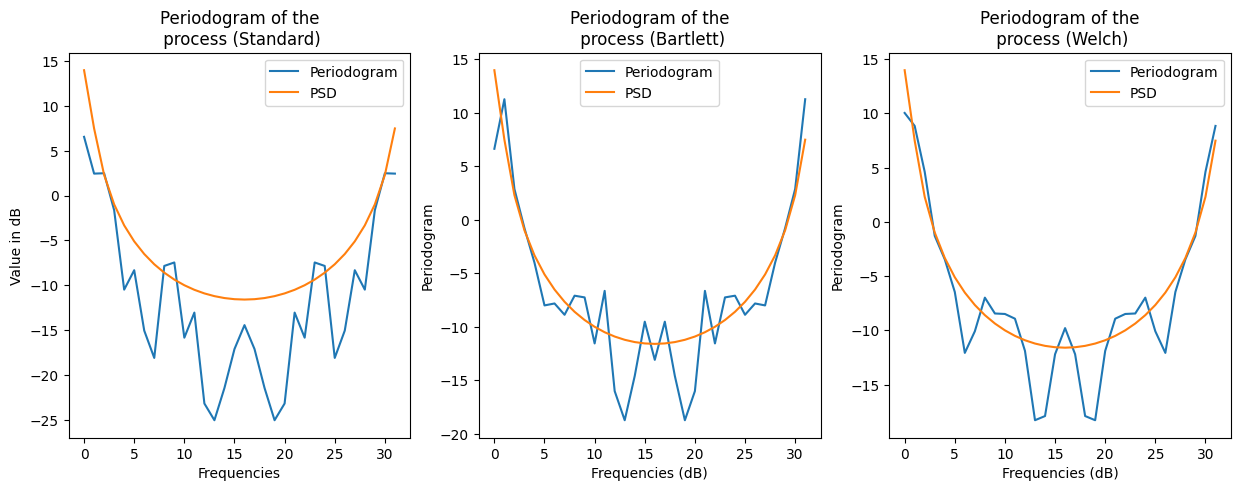

In [473]:
M=32
plot_periodogram_AR1(X, N, M)

4. Comparison


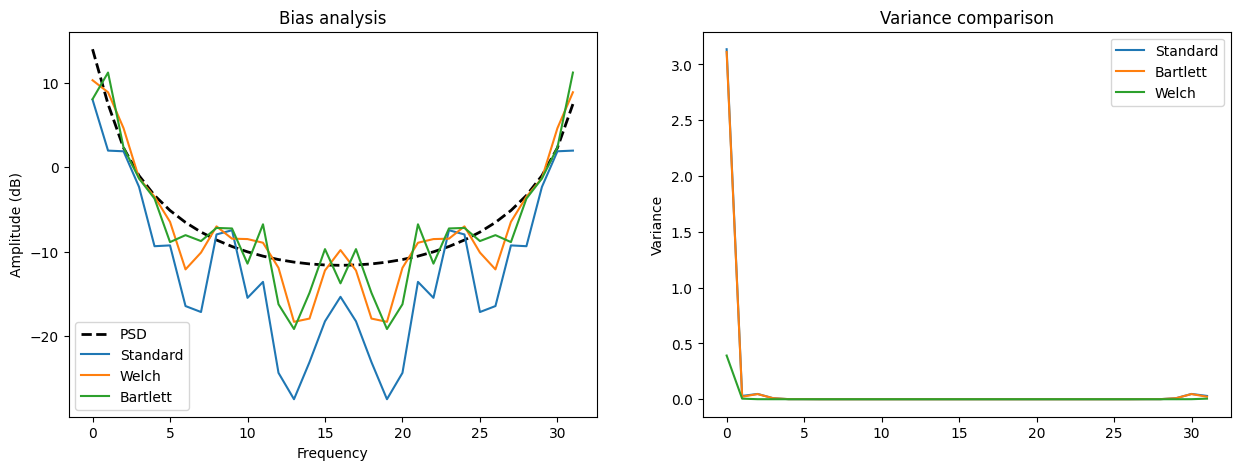

In [474]:
num=100
P_stds = np.zeros((num, M))
P_welchs = np.zeros((num, M))
P_barts = np.zeros((num, M))
for i in range(num):
    X = synthetise_AR(N, coeffs, e, sigma)
    P_stds[i,:] = periodogram(X, N, M, method="")
    P_welchs[i,:] = periodogram(X, N, M, method="welch")
    P_barts[i,:] = periodogram(X, N, M, method="bart")
PSD = np.array([(sigma**2)/np.abs(1-coeffs*np.exp(-2 * 1j* np.pi * (k/M)))**2 for k in range(M)])
mean_std = np.mean(P_stds, axis=0)
mean_welch = np.mean(P_welchs, axis=0)
mean_bart = np.mean(P_barts, axis=0)

var_std = np.var(P_stds, axis=0)
var_welch = np.var(P_welchs, axis=0)
var_bart = np.var(P_barts, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(10*np.log10(PSD), 'k--', linewidth=2, label="PSD")
axes[0].plot(10*np.log10(mean_std), label="Standard")
axes[0].plot(10*np.log10(mean_welch), label="Welch")
axes[0].plot(10*np.log10(mean_bart), label="Bartlett")
axes[0].set_title("Bias analysis")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Amplitude (dB)")
axes[0].legend()

axes[1].plot(var_std, label="Standard")
axes[1].plot(var_bart, label="Bartlett")
axes[1].plot(var_welch, label="Welch")
axes[1].set_title("Variance comparison")
axes[0].set_xlabel("Frequency")
axes[1].set_ylabel("Variance")
axes[1].legend()

plt.show()

In [475]:
print(f"Bias of the standard method: {np.mean(PSD-mean_std)}")
print(f"Bias of the welch method: {np.mean(PSD-mean_welch)}")
print(f"Bias of the bart method: {np.mean(PSD-mean_bart)}")

print(f"Variance of the standard method: {np.mean(var_std)}")
print(f"Variance of the welch method: {np.mean(var_welch)}")
print(f"Variance of the bart method: {np.mean(var_bart)}")

Bias of the standard method: 0.9336741523591044
Bias of the welch method: 0.25845549329283213
Bias of the bart method: 0.12102482408588064
Variance of the standard method: 0.10349618942084796
Variance of the welch method: 0.012570801504344063
Variance of the bart method: 0.10220769601053285


**COMMENT :** According to the previous results, we conclude that :

The closest bias to zero is the welch method, it is also the one with the lowest variance. While the standard method has the further bias from 0 and has the highest variance.

### 1.3 Parametric estimation : linear prediction

5. Estimating the AR model


In [476]:
estimated_AR = lpc(X, order=1)
print(estimated_AR)

[ 1.         -0.91958954]


we find a coefficient of -0.86 which is close to the -0.9 for the real AR(1) process.

6. Superposing spectral envelope and periodogram

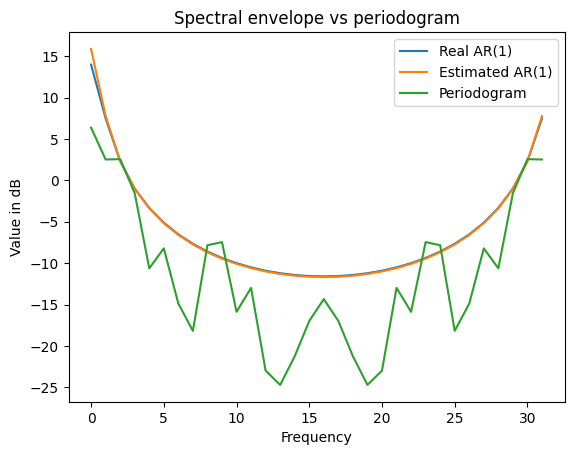

In [477]:
exact_PSD = np.array([(sigma**2)/np.abs(1-coeffs*np.exp(-2 * 1j* np.pi * (k/M)))**2 for k in range(M)])
estimated_PSD = np.array([(sigma**2)/np.abs(1+estimated_AR[1]*np.exp(-2 * 1j* np.pi * (k/M)))**2 for k in range(M)])
p=periodogram(X, N, M, method="")

plt.plot(10*np.log10(exact_PSD))
plt.plot(10*np.log10(estimated_PSD))
plt.plot(10*np.log10(p))
plt.legend(["Real AR(1)", "Estimated AR(1)", "Periodogram"])
plt.xlabel("Frequency")
plt.ylabel("Value in dB")
plt.title("Spectral envelope vs periodogram")
plt.show()

**Comment :** The Real AR(1) spectral envelope and the estimated one are very close to each other. They are aligned except in the extremities.

They represent the smooth curve that the periodogram (non smooth) kind of follows.

### 1.4 Application to speech signals

7. Application to speech signals

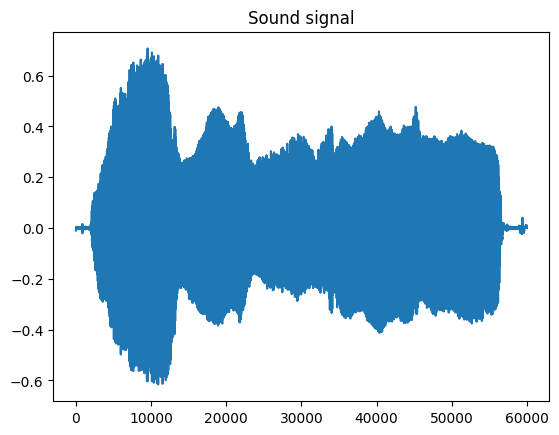

In [478]:
sound, salmpling_rate = librosa.load("sounds/aeiou.wav", sr=None)

plt.Figure()
plt.plot(sound)
plt.title("Sound signal")
plt.show()

We see here that the signal ranges from approximatively 5000 to 13000. In order to avoid the problems with the extremities (the change in the voice since it starts saying "a" or it ends saying "a"), we will choose [8000 - 11000]

In [479]:
X_sound = sound[8000:11000]
N_sound = len(X); M_sound=N_sound
p = periodogram(X_sound, N_sound, M_sound, method="standard")
p_welch = periodogram(X_sound, N_sound, M_sound, method="welch")

order=12
coeffs_sound = lpc(X_sound, order=order)
h = np.zeros_like(coeffs_sound)
h[1:]=-coeffs_sound[1:]
X_pred = np.convolve(X_sound, h, mode="full")[:len(X_sound)]
sigma_err=np.std(X_sound-X_pred)
A_f = np.fft.fft(coeffs_sound, n=M_sound)
PSD_est = (sigma_err**2) / (np.abs(A_f)**2)

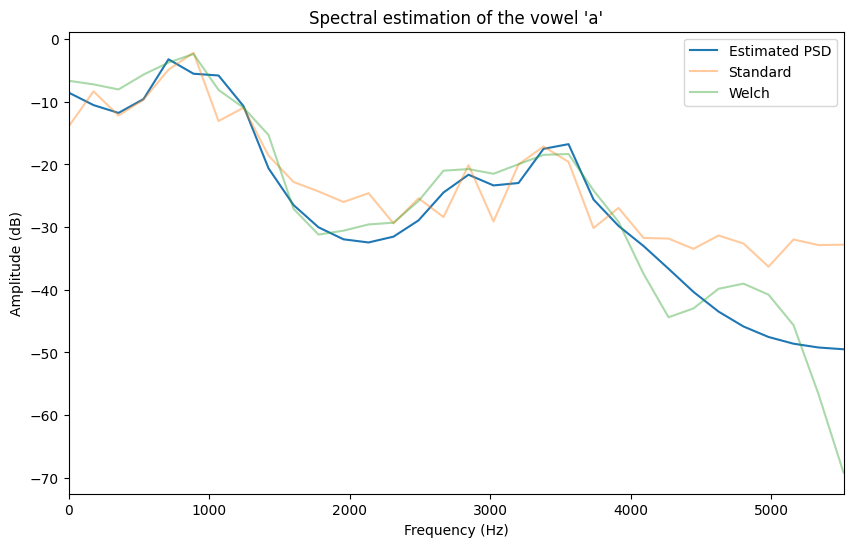

In [480]:
freqs = np.linspace(0, salmpling_rate/2, M_sound//2)

plt.figure(figsize=(10, 6))
# On ne prend que la moitié des tableaux : [:M_vowel//2]
plt.plot(freqs, 10*np.log10(PSD_est[:M_sound//2]), label="Estimated PSD")
plt.plot(freqs, 10*np.log10(p[:M_sound//2]), label="Standard", alpha=0.4)
plt.plot(freqs, 10*np.log10(p_welch[:M_sound//2]), label="Welch", alpha=0.4)

plt.title("Spectral estimation of the vowel 'a'")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xlim(0, salmpling_rate/2)
plt.legend()
plt.show()

We can see that the periodogram follows the estimated PSD. This means that our estimation is good. We correctly managed to extract the "a" vowel from the sound file and managed to estimate a smoother curve (PSD) that represents the signal.

## 1. Sum of noisy sinusoids

### 2.1 Synthesis

In [481]:
def synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma):
    s = 0; K = len(frequencies)
    for i in range(K):
        s+= amplitudes[i] * np.array([np.cos(2*np.pi*frequencies[i]*(k/N)+origin_phases[i]) for k in range(N)])
    s += np.random.normal(0, sigma, N)
    return s

In [482]:
N=64
frequencies = np.linspace(10, 100, N)
amplitudes = 10*np.random.random(N)
origin_phases = np.random.random(N)
sigma=0.5
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
print(X)

[282.735413   -52.65661752 -26.23950351  -8.13062637   6.76607474
  -0.80470688 -14.92110637  16.82473203  15.03022911 -24.68666846
  12.52020207   5.87385046  -6.96229485  -3.19213091   5.52292726
  -2.54640905  33.84505618 -19.28949651  17.38053569 -27.69333246
 -21.51727435  16.80561127  22.13434468   3.47691971 -17.57954158
 -24.79277358  15.17536851  16.19741832  13.18094917 -35.06783903
  -1.63168764 -24.01449786  26.73212256  -9.04207735   0.61230813
  15.26577621  -4.28425824   8.91886479 -29.58114877  -1.21145207
  28.90653061   2.96726055  48.75436417 -24.12973715  15.5744731
  -6.30641357 -12.8461074  -66.57458021   8.45242291  24.89773744
 -15.33080491  -1.64862714  40.84801175   5.38609667 -11.98285879
  10.38578915 -20.08853603   4.30412194   4.48572195  19.77415151
  13.52909105   4.28670793  13.88257176  13.28037218]


### 2.2 Non parametric estimation : periodogram

2. Periodograms

In [483]:
N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
print(X)

[ 0.33058888  0.43785165  1.25703378 -0.17159929 -0.05997858 -1.58960182
  0.77588767 -0.47983933 -0.37329088 -0.00677976  1.96158506  0.67472305
  0.51777768  3.07776246 -1.27201671 -1.8955752   0.73671465 -0.82417306
 -1.2183642   1.10119419 -1.25201681 -0.50009071  0.67979806 -0.34819501
 -0.60897388  0.32403202  0.44546867 -1.15339413 -2.33684116  1.84946596
 -0.81153495 -1.55778938  0.39787334 -0.29756453 -0.40431436  1.15380734
 -0.73983448  0.50496974  4.09382953 -0.73315532 -1.39312222  0.14239403
  1.36251638  0.44523211 -1.01239016  1.6405769   0.61547605 -0.76315045
  3.99915723 -0.46316742 -1.79503231  3.26316347  0.68956141  0.29259789
  1.10312848 -0.98353576  2.10026939 -0.23555093  1.46462369  0.19944161
 -0.12847953  1.26278556 -1.24515929 -0.0123953 ]


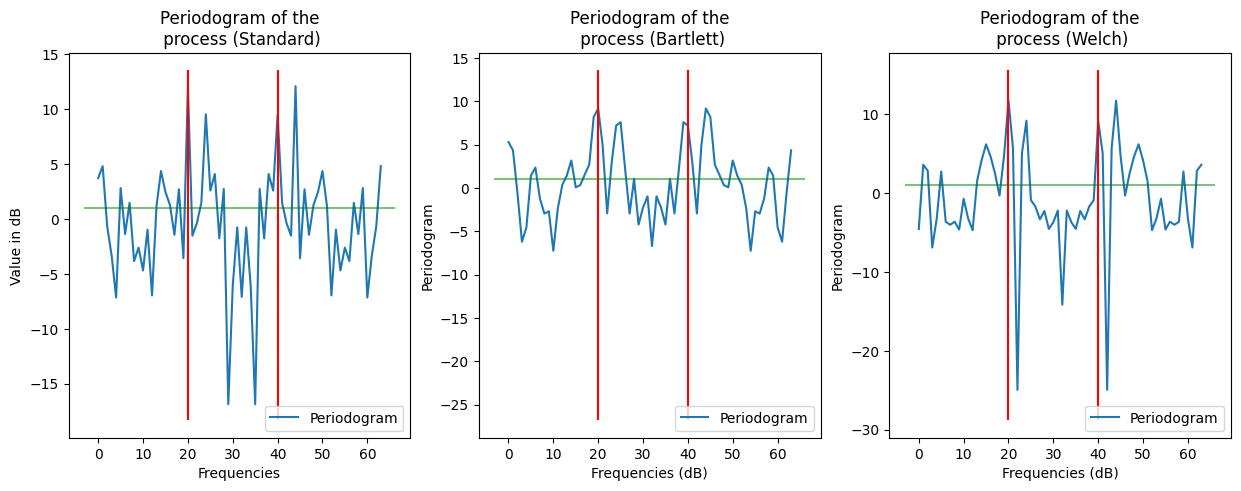

In [484]:
def plot_periodogram_sinusoids(X, N, M, frequencies):
    p0 = periodogram(X, N, M, "")
    p1 = periodogram(X, N, M, "bart")
    p2 = periodogram(X, N, M, "welch")
    fig, axes=plt.subplots(1,3, figsize=(15,5))
    axes[0].plot(10*np.log10(p0))
    axes[0].set_title("Periodogram of the\n process (Standard)")
    axes[0].set_xlabel("Frequencies")
    axes[0].set_ylabel("Value in dB")
    axes[0].legend(["Periodogram"], loc="lower right")

    axes[1].plot(10*np.log10(p1))
    axes[1].set_title("Periodogram of the\n process (Bartlett)")
    axes[1].set_xlabel("Frequencies (dB)")
    axes[1].set_ylabel("Periodogram")
    axes[1].legend(["Periodogram"], loc="lower right")

    axes[2].plot(10*np.log10(p2))
    axes[2].set_title("Periodogram of the\n process (Welch)")
    axes[2].set_xlabel("Frequencies (dB)")
    axes[2].set_ylabel("Periodogram")
    axes[2].legend(["Periodogram"], loc="lower right")
    x_min, x_max, y_min, y_max = axes[0].axis()
    axes[0].vlines(frequencies, y_min, y_max, "red")
    axes[0].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)
    _, _, y_min, y_max = axes[2].axis()
    axes[1].vlines(frequencies, y_min, y_max, "red")
    axes[1].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)
    _, _, y_min, y_max = axes[1].axis()
    axes[2].vlines(frequencies, y_min, y_max, "red")
    axes[2].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)

    plt.show()

plot_periodogram_sinusoids(X, N, M, frequencies)

3. Comparison

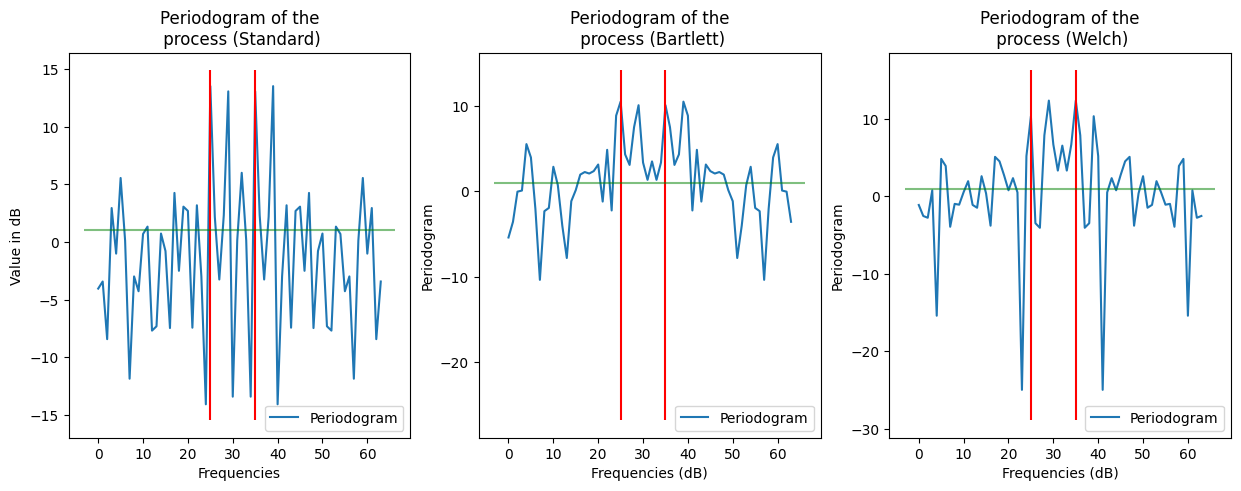

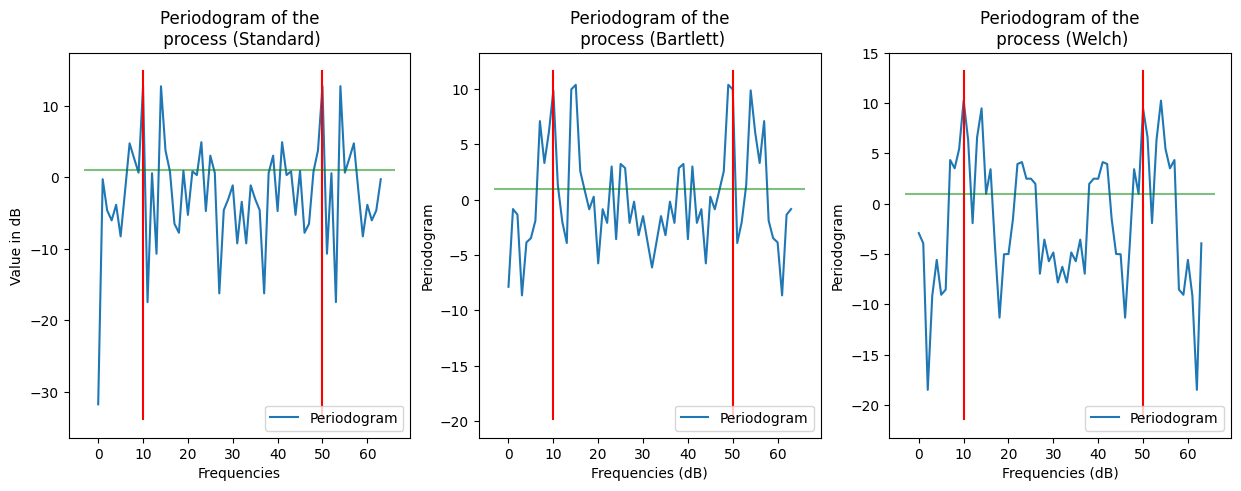

In [485]:
# Higher difference of frequencies

N=64;M=N
frequencies = np.array([25, 35])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_periodogram_sinusoids(X, N, M, frequencies)

# Lower difference of frequencies

N=64;M=N
frequencies = np.array([10, 50])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_periodogram_sinusoids(X, N, M, frequencies)

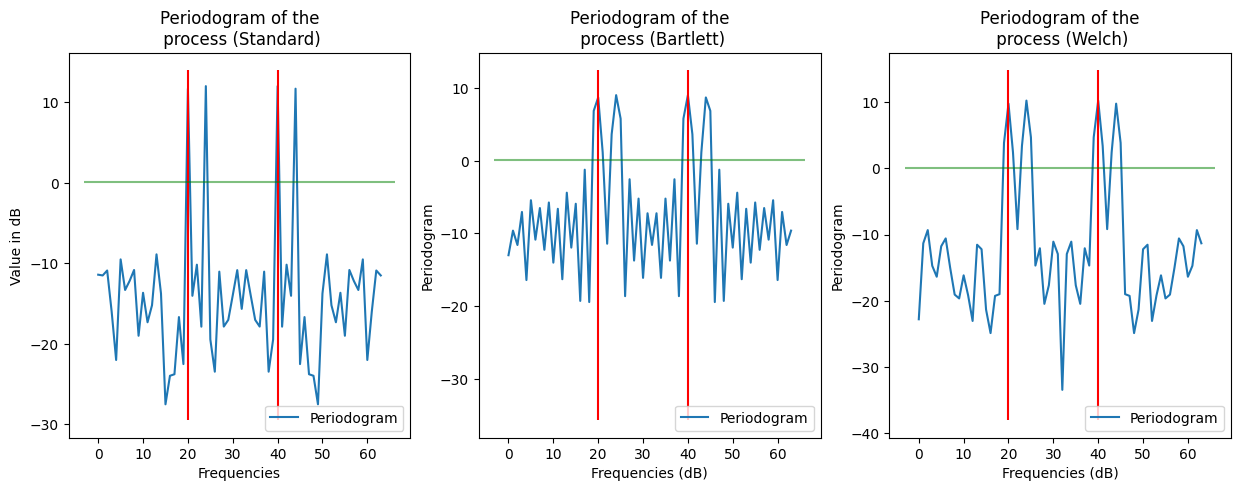

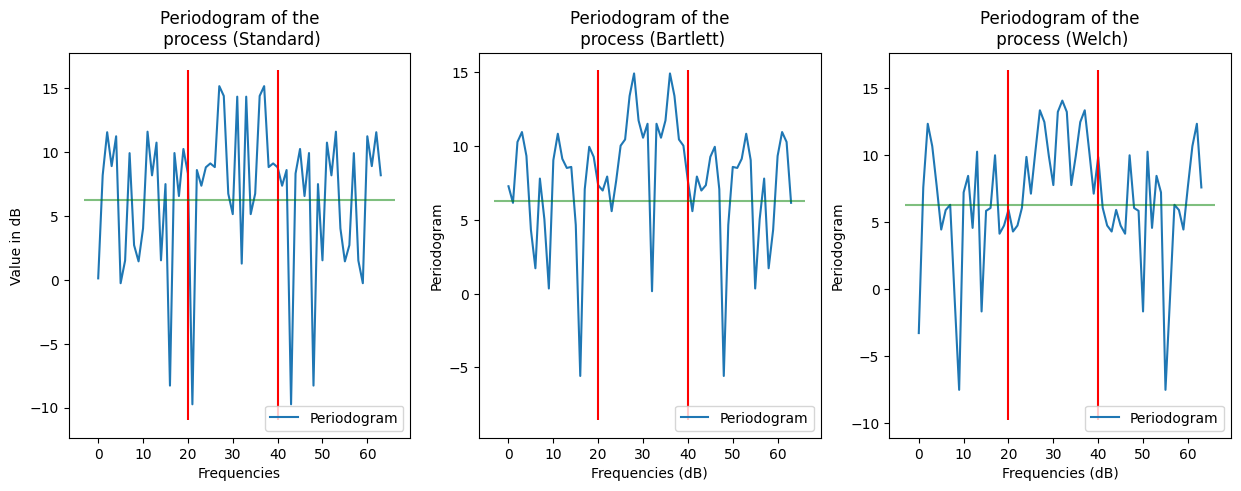

In [486]:
# Higher SNR = lower sigma

N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=0.2
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_periodogram_sinusoids(X, N, M, frequencies)

# Lower SNR = higher sigma

N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=2.5
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_periodogram_sinusoids(X, N, M, frequencies)

**COMMENTS :**

We see that, by varying the difference $\Delta \nu=|\nu_1-\nu_2|$ :
- The resolution gets lower for the other methods as long as we increase the difference.
- The standard method has the highest resolution.

We see that, by varying the difference $\sigma^2$ :
- The resolution increase for the other methods as long as we decrease $\sigma^2$ (i.e increase SNR).
- The standard method has the highest resolution, while the welch method has the lowest resolution, which can be seen for the bigger $\sigma^2$ values.

### 2.3 Parametric estimation : linear prediction

4. AR(4) process estimation

In [487]:
def estimate_AR4_process(X, N, sigma):
    est_coeffs= lpc(X, order=4)
    new_coeffs = -est_coeffs[1:]
    Z = (sigma**2) * np.random.randn(N)
    return synthetise_AR(N, new_coeffs, Z, sigma)

def new_plot_periodogram(X, N, M, sigma, frequencies):
    X_est = estimate_AR4_process(X, N, sigma)
    p0 = periodogram(X, N, M, "")
    p0_est = periodogram(X_est, N, M, "")
    p1 = periodogram(X, N, M, "bart")
    p1_est = periodogram(X_est, N, M, "bart")
    p2 = periodogram(X, N, M, "welch")
    p2_est = periodogram(X_est, N, M, "welch")
    fig, axes=plt.subplots(1,3, figsize=(20,5))
    axes[0].plot(10*np.log10(p0))
    axes[0].plot(10*np.log10(p0_est))
    axes[0].set_title("Periodogram of the\n process (Standard)")
    axes[0].set_xlabel("Frequencies")
    axes[0].set_ylabel("Value in dB")
    axes[0].legend(["Real Periodogram", "Estimated Periodogram"], loc="lower right")

    axes[1].plot(10*np.log10(p1))
    axes[1].plot(10*np.log10(p1_est))
    axes[1].set_title("Periodogram of the\n process (Bartlett)")
    axes[1].set_xlabel("Frequencies (dB)")
    axes[1].set_ylabel("Periodogram")
    axes[1].legend(["Real Periodogram", "Estimated Periodogram"], loc="lower right")

    axes[2].plot(10*np.log10(p2))
    axes[2].plot(10*np.log10(p2_est))
    axes[2].set_title("Periodogram of the\n process (Welch)")
    axes[2].set_xlabel("Frequencies (dB)")
    axes[2].set_ylabel("Periodogram")
    axes[2].legend(["Real Periodogram", "Estimated Periodogram"], loc="lower right")
    x_min, x_max, y_min, y_max = axes[0].axis()
    axes[0].vlines(frequencies, y_min, y_max, "red")
    axes[0].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)
    _, _, y_min, y_max = axes[2].axis()
    axes[1].vlines(frequencies, y_min, y_max, "red")
    axes[1].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)
    _, _, y_min, y_max = axes[1].axis()
    axes[2].vlines(frequencies, y_min, y_max, "red")
    axes[2].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)

    plt.show()

5. Superposition

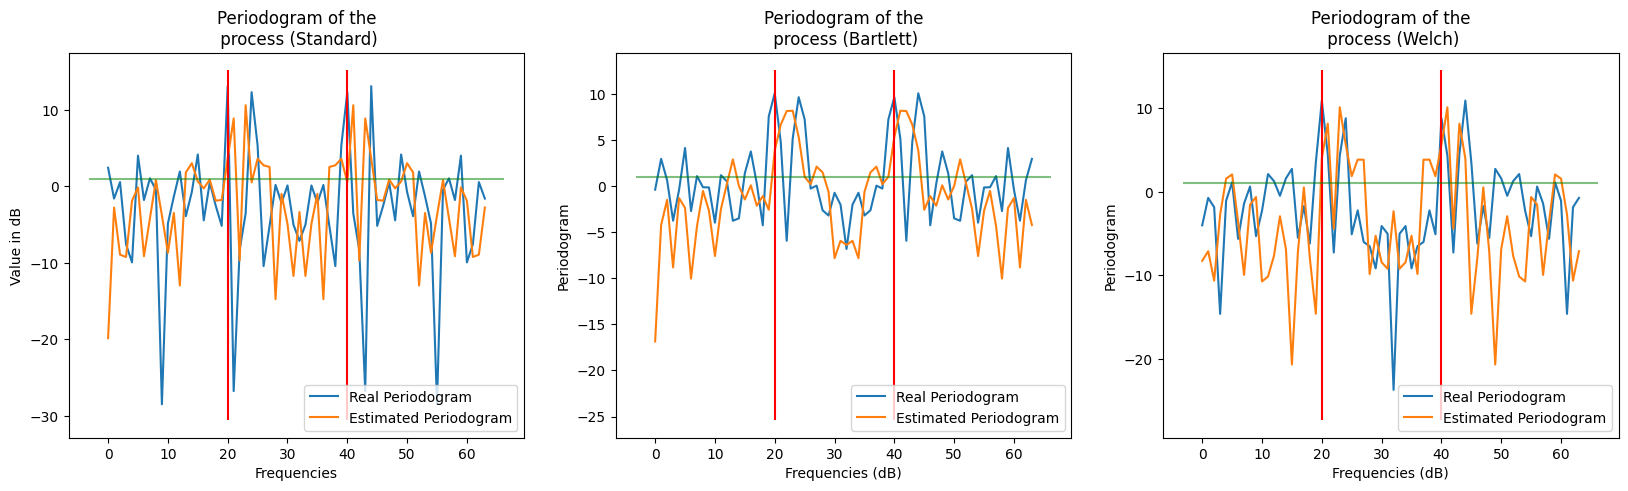

In [488]:
N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
new_plot_periodogram(X, N, M, sigma, frequencies)

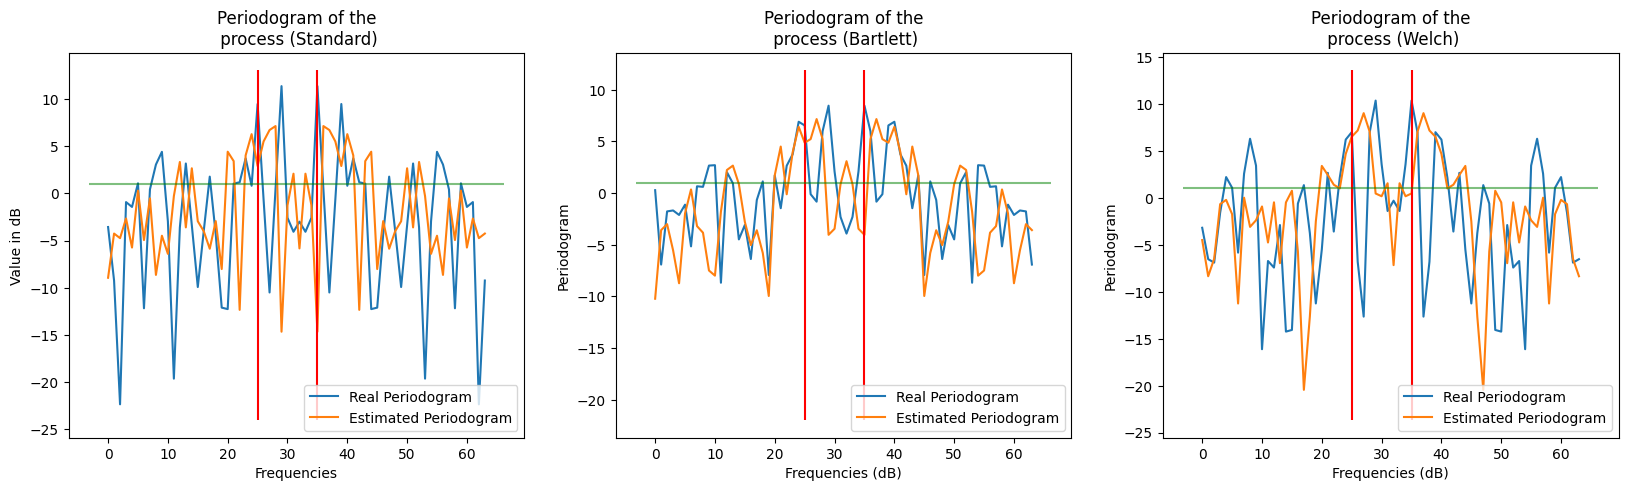

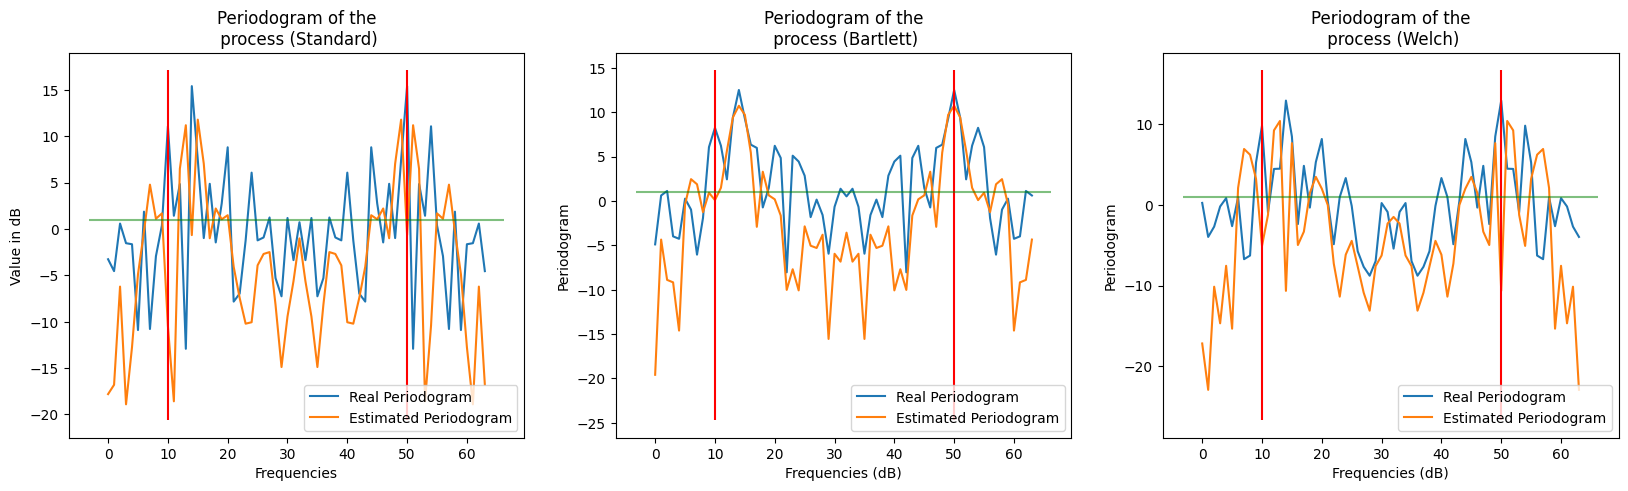

In [489]:
# Lower difference
N=64;M=N
frequencies = np.array([25, 35])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
new_plot_periodogram(X, N, M, sigma, frequencies)

# Higher difference
N=64;M=N
frequencies = np.array([10, 50])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
new_plot_periodogram(X, N, M, sigma, frequencies)

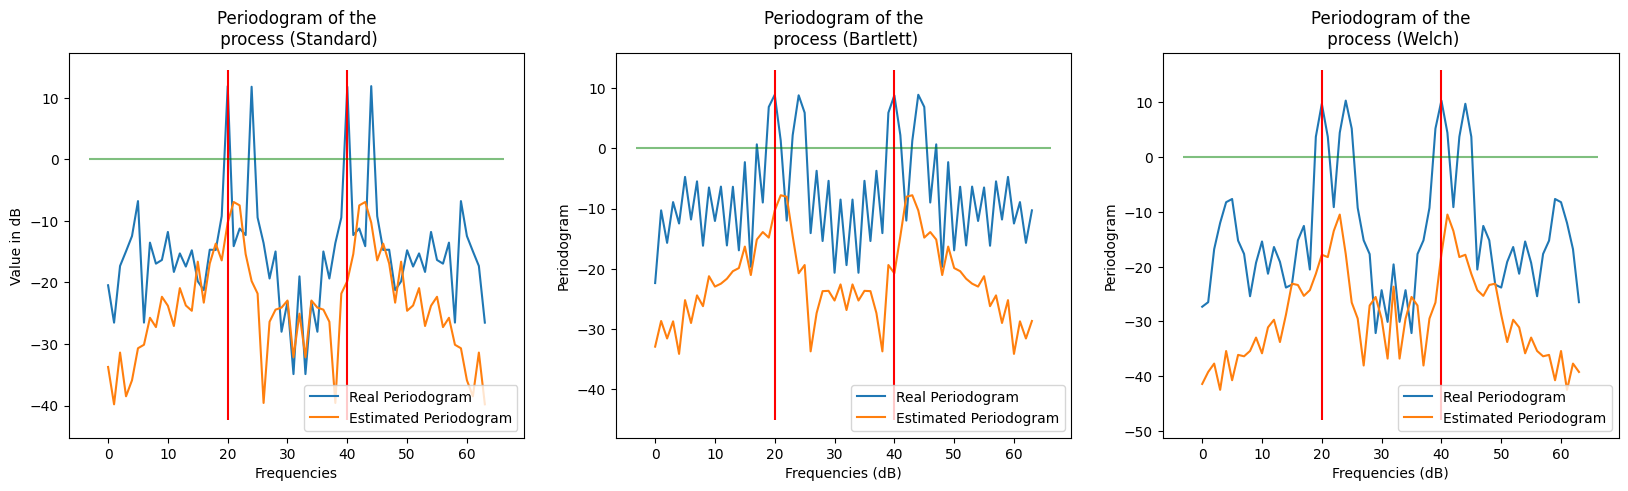

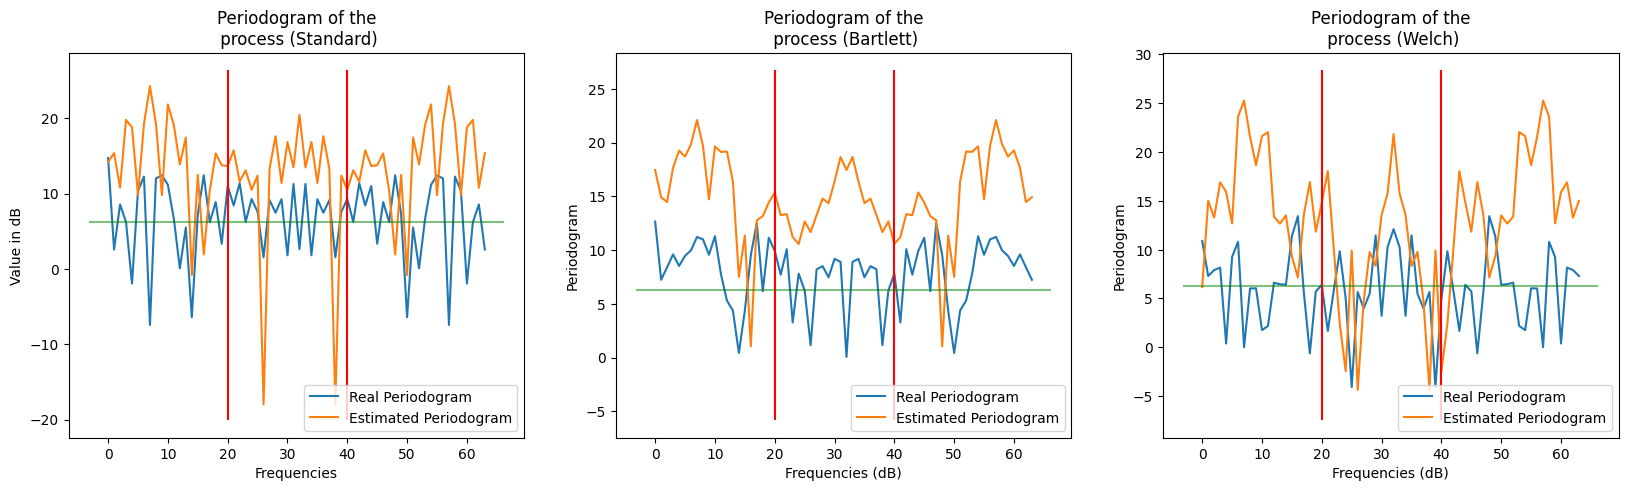

In [490]:
# Higher SNR = lower sigma

N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=0.2
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
new_plot_periodogram(X, N, M, sigma, frequencies)

# Lower SNR = higher sigma

N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=2.5
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
new_plot_periodogram(X, N, M, sigma, frequencies)

**COMMENTS :**

When the $\sigma$ is big (SNR small) we see that the estimated periodogram have more intense values than the real one.

The result is pretty good for a moderate value of $\sigma$ even when varying a little bit the $\Delta \nu$

### 2.4 Parametric estimation : Capon estimator
6. Capon estimator function

In [491]:
def capon_estimator(X, n, ksi):
    L = len(X)
    K = L - n + 1
    e_ksi = np.array([np.exp(2*1j*np.pi*ksi*k) for k in range(n)])
    new_X = np.array([X[i : i+n] for i in range(K)]).T
    Rxx = (new_X @ new_X.conj().T)/n
    Rxx_inv = np.linalg.inv(Rxx)
    P = 1/(e_ksi.conj().T @ Rxx_inv @ e_ksi)
    return np.real(P)

def plot_capon_periodogram(X, n, M, sigma, frequencies):
    N = len(X)
    P = np.array([capon_estimator(X, n, k/M) for k in range(M)])

    p0 = periodogram(X, N, M, "")
    p1 = periodogram(X, N, M, "bart")
    p2 = periodogram(X, N, M, "welch")
    fig, axes=plt.subplots(1,3, figsize=(20,5))
    axes[0].plot(10*np.log10(p0))
    axes[0].plot(10*np.log10(P))
    axes[0].set_title("Periodogram of the\n process (Standard)")
    axes[0].set_xlabel("Frequencies")
    axes[0].set_ylabel("Value in dB")
    axes[0].legend(["Real Periodogram", "Capon"], loc="lower right")

    axes[1].plot(10*np.log10(p1))
    axes[1].plot(10*np.log10(P))
    axes[1].set_title("Periodogram of the\n process (Bartlett)")
    axes[1].set_xlabel("Frequencies (dB)")
    axes[1].set_ylabel("Periodogram")
    axes[1].legend(["Real Periodogram", "Capon"], loc="lower right")

    axes[2].plot(10*np.log10(p2))
    axes[2].plot(10*np.log10(P))
    axes[2].set_title("Periodogram of the\n process (Welch)")
    axes[2].set_xlabel("Frequencies (dB)")
    axes[2].set_ylabel("Periodogram")
    axes[2].legend(["Real Periodogram", "Capon"], loc="lower right")
    x_min, x_max, y_min, y_max = axes[0].axis()
    axes[0].vlines(frequencies, y_min, y_max, "red")
    axes[0].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)
    _, _, y_min, y_max = axes[2].axis()
    axes[1].vlines(frequencies, y_min, y_max, "red")
    axes[1].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)
    _, _, y_min, y_max = axes[1].axis()
    axes[2].vlines(frequencies, y_min, y_max, "red")
    axes[2].hlines(sigma**2, x_min, x_max, "green", alpha=0.5)

    plt.show()

7. Comparison

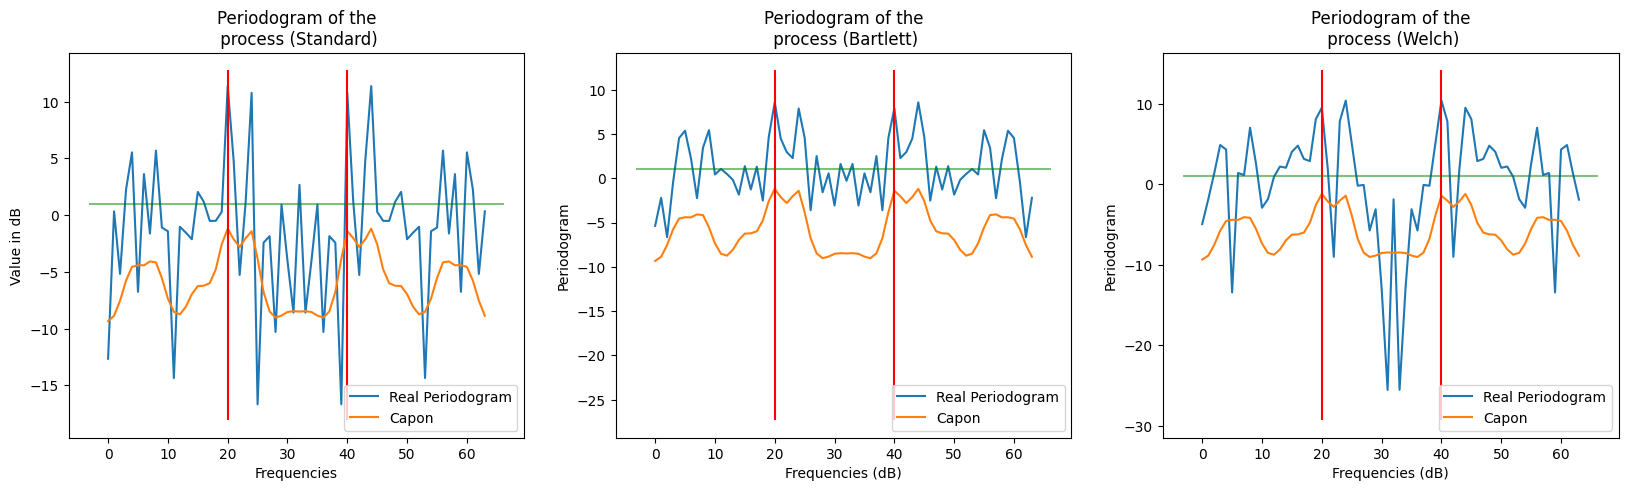

In [492]:
N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
n = 16
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_capon_periodogram(X, n, M, sigma, frequencies)

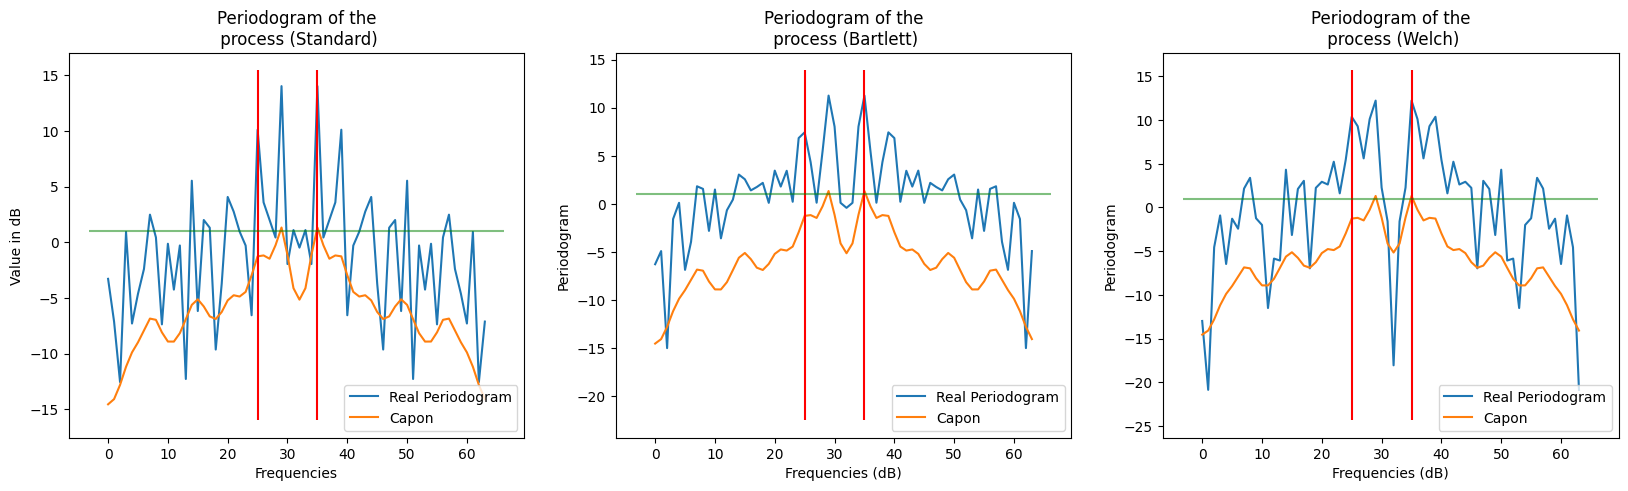

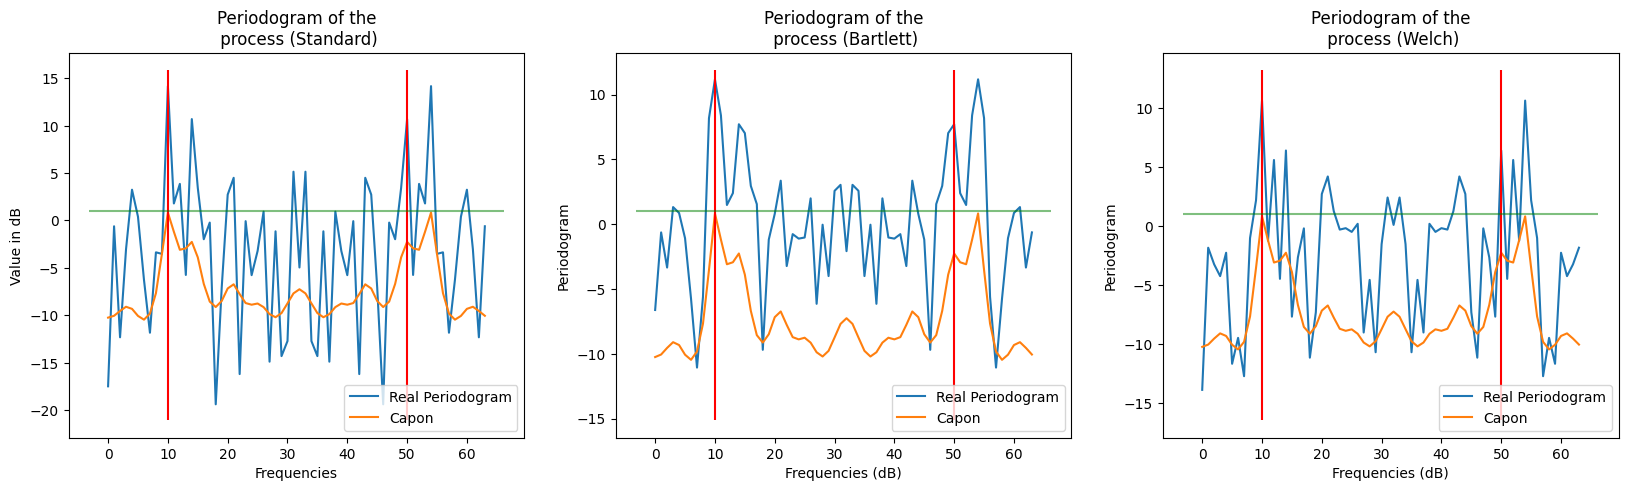

In [493]:
# Lower difference
N=64;M=N
frequencies = np.array([25, 35])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_capon_periodogram(X, n, M, sigma, frequencies)

# Higher difference
N=64;M=N
frequencies = np.array([10, 50])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=1.0
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_capon_periodogram(X, n, M, sigma, frequencies)

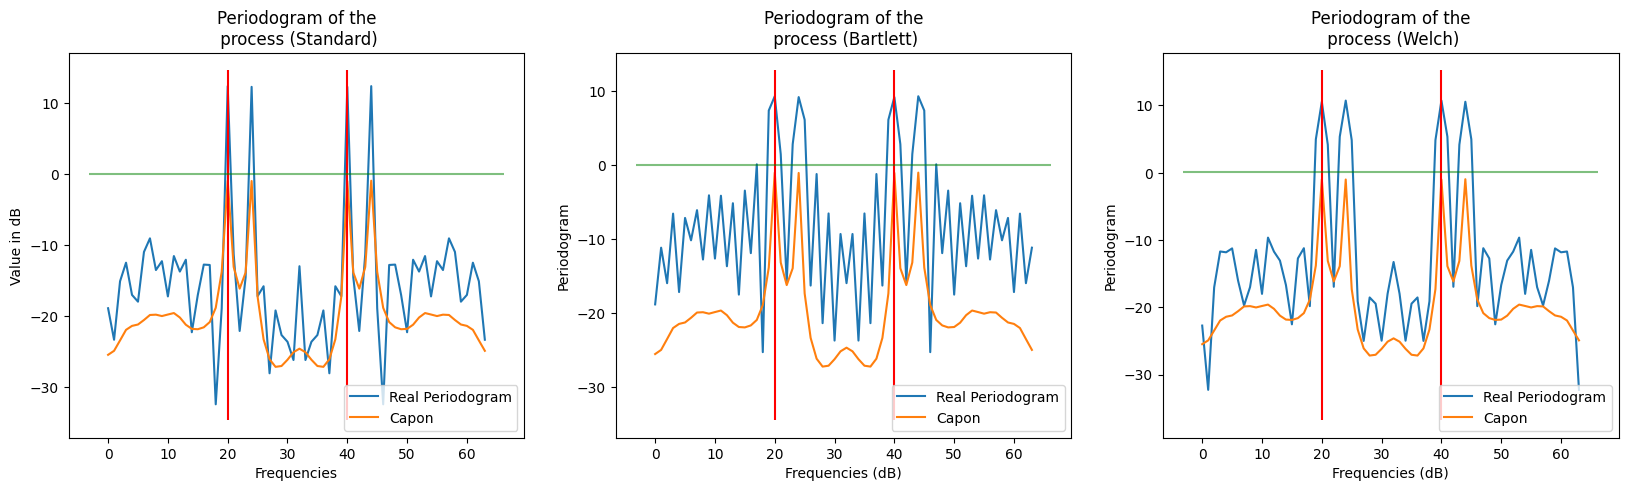

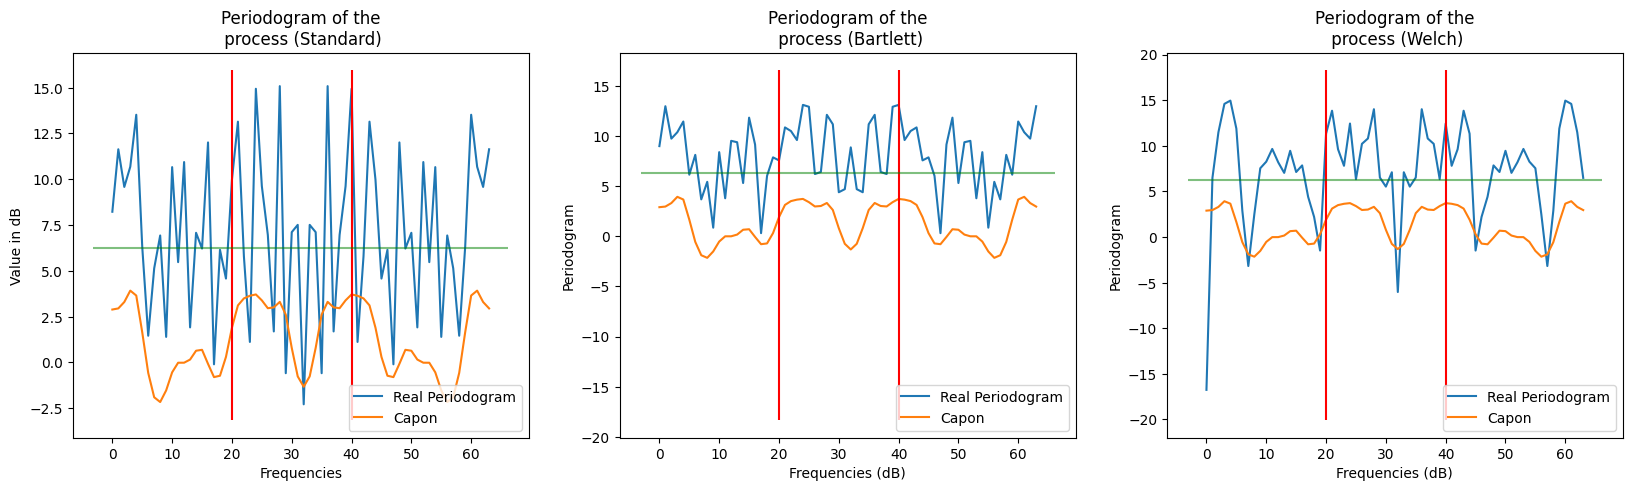

In [494]:
# Higher SNR = lower sigma

N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=0.2
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_capon_periodogram(X, n, M, sigma, frequencies)

# Lower SNR = higher sigma

N=64;M=N
frequencies = np.array([20, 40])
amplitudes = np.array([1,1])
origin_phases = np.zeros(2)
sigma=2.5
X = synthesize_sum_sinusoids(N, frequencies, amplitudes, origin_phases, sigma)
plot_capon_periodogram(X, n, M, sigma, frequencies)

**COMMENTS :** In terms of resolution, it is overall lower than any of the other methods except for the case of $\sigma$ low.



## 3. Autoregressive-moving-average process

### 3.1 Synthesis

In [495]:
def synthetise_ARMA(N, coeffs_AR, coeffs_MA, sigma, x0=None):
    Z = (sigma)*np.random.randn(N)
    if x0 is None:
        x0= np.zeros_like(Z)
        x0[:len(coeffs_AR)+len(coeffs_MA)]=np.random.normal(0, sigma, len(coeffs_AR)+len(coeffs_MA))
    start_idx = max(len(coeffs_AR), len(coeffs_MA))
    X = x0.copy()
    for i in range(start_idx, N):
        s = 0
        for j in range(len(coeffs_AR)):
            s+= coeffs_AR[j]*X[i-j-1]
        for j in range(len(coeffs_MA)):
            s+= coeffs_MA[j]*Z[i-j-1]
        s+=Z[i]
        X[i]=s
    return X

In [496]:
N=64
coeffs_AR=[0.9]
coeffs_MA=[-0.7]
sigma=0.5
X = synthetise_ARMA(N, coeffs_AR, coeffs_MA, sigma)
print(X)

[ 5.60015234e-01 -1.89474396e-04  6.90191789e-01  4.41271304e-01
  7.35622880e-01  1.98712841e-01 -1.63763519e-01 -3.14466595e-01
  6.41143255e-01 -3.93085447e-02  1.80920325e-02  4.96053923e-01
  5.15932348e-01  1.33798374e+00 -2.40225030e-02  1.37381608e+00
  1.67440495e+00  4.55534730e-01  8.98317708e-01  7.70151898e-01
  6.03844212e-01  3.35533850e-01  6.01850663e-01  7.75173474e-01
 -1.04195680e-01  7.49443293e-01  6.05078684e-01  4.69860321e-01
  3.17438056e-01  4.66660685e-01  8.90504344e-01 -2.02948474e-01
  8.97608816e-02  1.51241646e-01 -3.45753188e-01 -1.07925687e+00
 -6.25938552e-01 -7.74994199e-01  9.18263058e-02  2.81692044e-01
 -1.22272199e-01 -2.11123563e-01 -1.29897857e-02  1.60618935e-01
 -8.47044013e-01 -1.55356747e-01 -2.46694766e-01 -4.02693033e-01
 -3.03806709e-01 -7.28737716e-01 -7.55990705e-01 -1.10204125e+00
 -4.55970055e-01 -1.25809497e-01  2.18168761e-01  6.75139636e-02
  2.19550597e-01  8.27221604e-01 -8.23914734e-02 -6.44747795e-01
 -7.65972754e-01 -2.84597

### 3.2 Non-parametric estimation : periodogram
2. Periodograms

/home/mkhales-24/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/mkhales-24/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


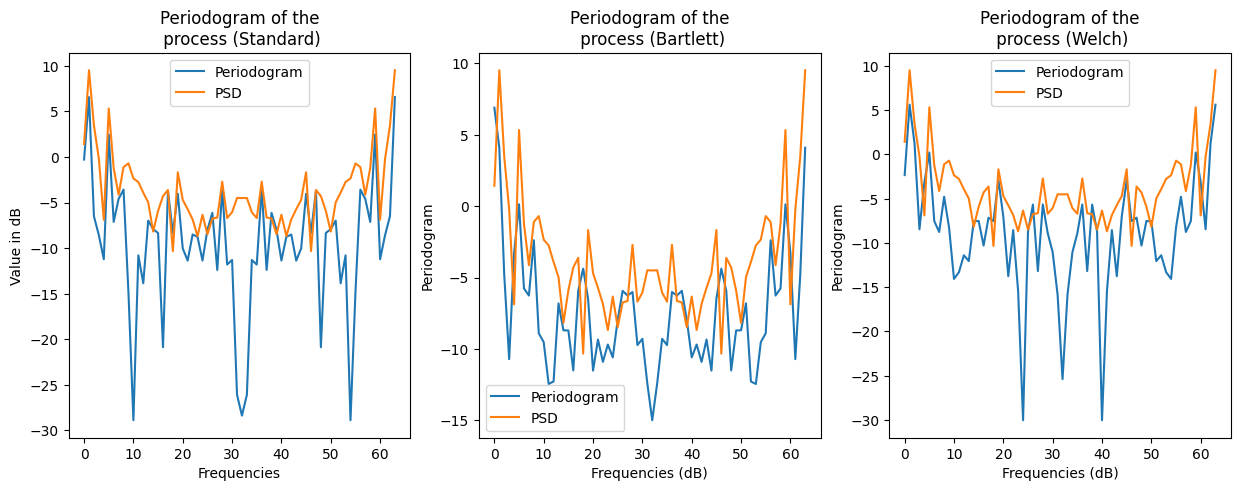

In [497]:
plot_periodogram(X, N, N, "all")

3. Comparison in terms of bias and variance

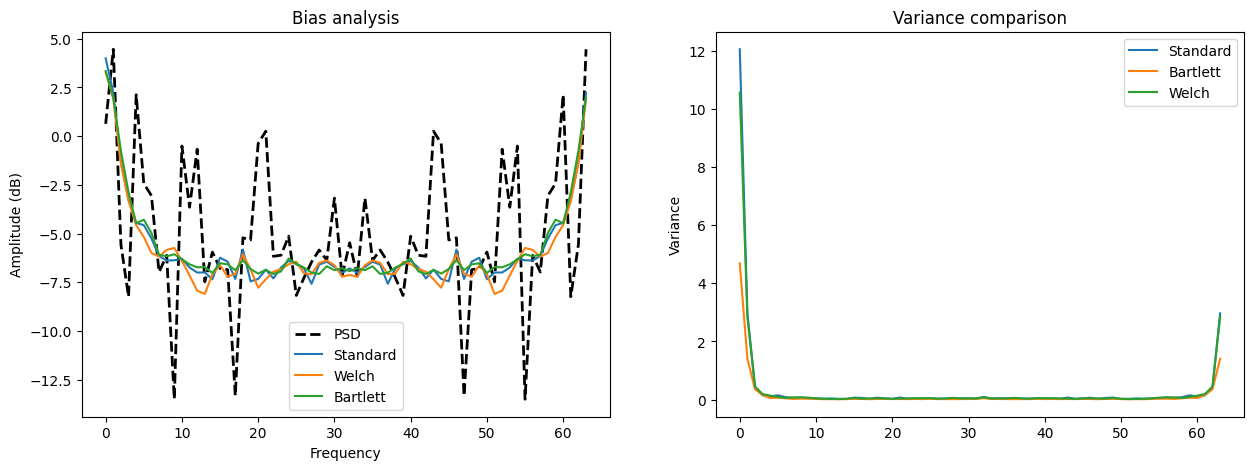

In [498]:
num=100
P_stds = np.zeros((num, M))
P_welchs = np.zeros((num, M))
P_barts = np.zeros((num, M))
for i in range(num):
    X = synthetise_ARMA(N, coeffs_AR, coeffs_MA, sigma)
    P_stds[i,:] = periodogram(X, N, N, method="")
    P_welchs[i,:] = periodogram(X, N, N, method="welch")
    P_barts[i,:] = periodogram(X, N, N, method="bart")
autocov = 1/N * np.array([np.sum([X[(t+k)%N]*X[t%N] for t in range(1, N-k)])for k in range(-M+1, M)])
PSD = np.array([np.sum([autocov[j]*np.exp(-2*1j*np.pi* (k/M)*j) for j in range(len(autocov))])for k in range(M)])
mean_std = np.mean(P_stds, axis=0)
mean_welch = np.mean(P_welchs, axis=0)
mean_bart = np.mean(P_barts, axis=0)

var_std = np.var(P_stds, axis=0)
var_welch = np.var(P_welchs, axis=0)
var_bart = np.var(P_barts, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(10*np.log10(PSD), 'k--', linewidth=2, label="PSD")
axes[0].plot(10*np.log10(mean_std), label="Standard")
axes[0].plot(10*np.log10(mean_welch), label="Welch")
axes[0].plot(10*np.log10(mean_bart), label="Bartlett")
axes[0].set_title("Bias analysis")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Amplitude (dB)")
axes[0].legend()

axes[1].plot(var_std, label="Standard")
axes[1].plot(var_bart, label="Bartlett")
axes[1].plot(var_welch, label="Welch")
axes[1].set_title("Variance comparison")
axes[0].set_xlabel("Frequency")
axes[1].set_ylabel("Variance")
axes[1].legend()

plt.show()

In [499]:
print(f"Bias of the standard method: {np.mean(PSD-mean_std)}")
print(f"Bias of the welch method: {np.mean(PSD-mean_welch)}")
print(f"Bias of the bart method: {np.mean(PSD-mean_bart)}")

print(f"Variance of the standard method: {np.mean(var_std)}")
print(f"Variance of the welch method: {np.mean(var_welch)}")
print(f"Variance of the bart method: {np.mean(var_bart)}")

Bias of the standard method: (-0.14209427247714773-5.260548940899668e-16j)
Bias of the welch method: (-0.12582607175909183-5.260548940899668e-16j)
Bias of the bart method: (-0.14209427247714776-5.260548940899668e-16j)
Variance of the standard method: 0.3482875918846697
Variance of the welch method: 0.31861433098890374
Variance of the bart method: 0.15758428637991984


**COMMENTS:** We see that welch is still the method with the least bias and variance, while this time the standard method and bart method has the same bias, but the bart method has less variance than the standard method.

### 3.3 Parametric estimation : Durbin method
4. Durbin method code

In [500]:
def durbin_method(X, p, q):
    N=len(X)
    M=15
    autocor = np.correlate(X, X, mode='full')
    autocor = autocor[N-1:] / N
    vec1 = autocor[q+1:q+p+1]
    mat = np.array([[autocor[abs(q+i-j)] for j in range(p)]for i in range(p)])
    coeffs_AR=np.linalg.solve(mat, vec1)

    a_poly = np.concatenate(([1.0], -coeffs_AR))
    y = np.convolve(X, a_poly, mode='valid')
    Ny = len(y)
    y_autocor = np.correlate(y, y, mode='full')
    y_autocor = y_autocor[Ny-1:] / Ny
    R = np.array([[y_autocor[abs(i-j)] for j in range(M)]for i in range(M)])
    r = y_autocor[1:M+1]
    c = np.linalg.solve(R, r)

    c_poly = np.concatenate(([1.0], -c))
    c_autocor = np.correlate(c_poly, c_poly, mode='full')
    c_autocor = c_autocor[M:]
    R_MA = np.zeros((q, q))
    for i in range(q):
        for j in range(q):
            R_MA[i, j] = c_autocor[abs(i - j)]
            
    r_MA = c_autocor[1:q+1]
    coeffs_MA = np.linalg.solve(R_MA, -r_MA)

    return coeffs_AR, coeffs_MA

In [501]:
N=1024
coeffs_AR=[0.9]
coeffs_MA=[-0.7]
sigma=0.5
X = synthetise_ARMA(N, coeffs_AR, coeffs_MA, sigma)
coeffs_AR, coeffs_MA = durbin_method(X, 1,1)
print(coeffs_AR, coeffs_MA)

[0.90060589] [-0.72150056]


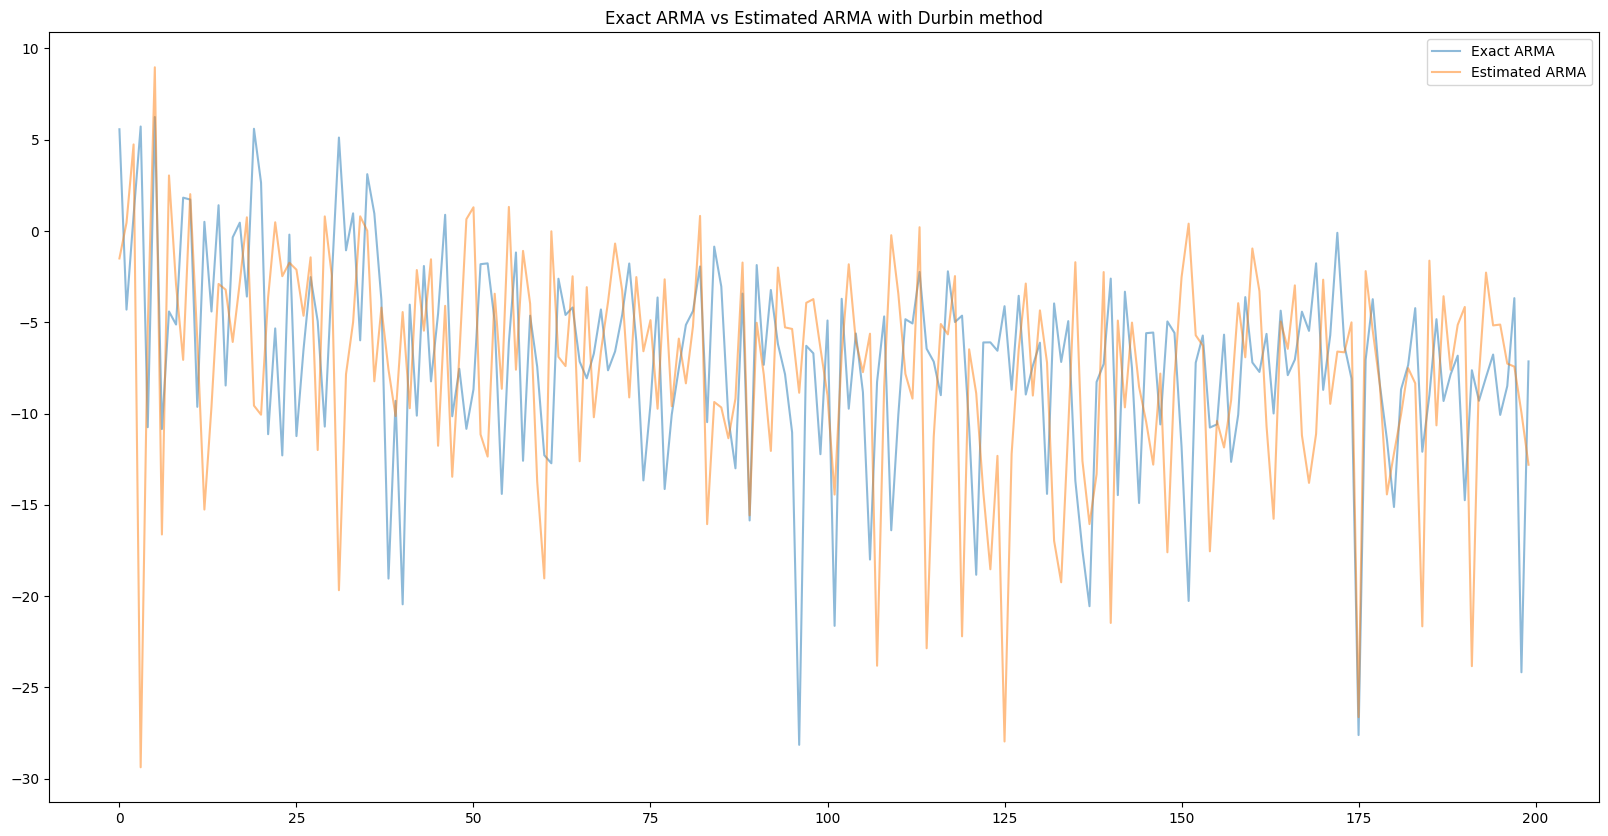

In [502]:
est_X = synthetise_ARMA(N, coeffs_AR, coeffs_MA, sigma)
pX = periodogram(X, N, N, method="")
pX_est =periodogram(est_X, N, N, method="")

fig, ax=plt.subplots(1,1,figsize=(20,10))

# Since We have too much elements, we restrict ourself to a size in order to compare better
size=200
ax.plot(10*np.log10(pX[:size]), label="Exact ARMA", alpha=0.5)
ax.plot(10*np.log10(pX_est[:size]), label = "Estimated ARMA", alpha=0.5)
ax.legend()
ax.set_title("Exact ARMA vs Estimated ARMA with Durbin method")
plt.show()

**COMMENTS :** We see a correlation between the two ARMA process. Even though the estimated one isn't exactly the real one, they are very similar. 

### 3.4 Application to speech signals
6. Application

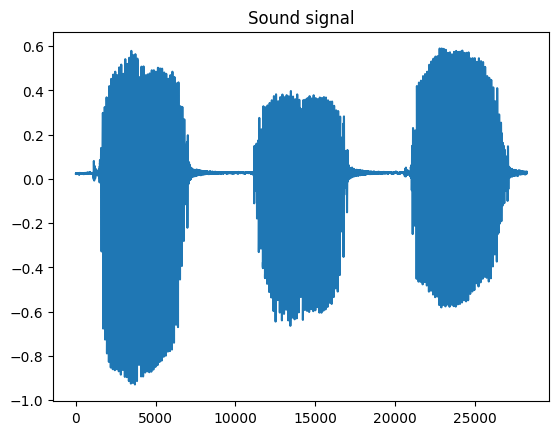

In [503]:
sound, sampling_rate = librosa.load("sounds/an_in_on.wav", sr=None)
freqs = np.linspace(0, sampling_rate/2, M_sound//2)

plt.Figure()
plt.plot(sound)
plt.title("Sound signal")
plt.show()

ValueError: x and y must have same first dimension, but have shapes (32,) and (1750,)

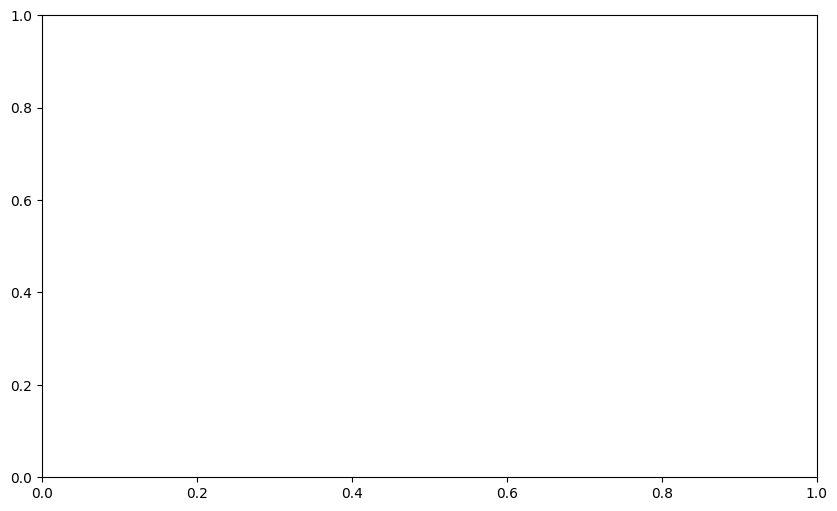

In [504]:
X_sound = sound[12500:16000]
N_sound = len(X_sound); M_sound=N_sound
p = periodogram(X_sound, N_sound, M_sound, method="standard")
p_welch = periodogram(X_sound, N_sound, M_sound, method="welch")

coeffs_AR, coeffs_MA = durbin_method(X_sound, 1,1)
est_X = synthetise_ARMA(N_sound, coeffs_AR, coeffs_MA, sigma)
p_est = periodogram(est_X, N_sound, M_sound, method="standard")

plt.figure(figsize=(10, 6))
# On ne prend que la moitié des tableaux : [:M_vowel//2]
plt.plot(freqs, 10*np.log10(p_est[:M_sound//2]), label="Estimated PSD")
plt.plot(freqs, 10*np.log10(p[:M_sound//2]), label="Standard", alpha=0.4)
plt.plot(freqs, 10*np.log10(p_welch[:M_sound//2]), label="Welch", alpha=0.4)

plt.title("Spectral estimation of the vowel 'a'")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xlim(0, sampling_rate/2)
plt.legend()
plt.show()

**COMMENTS :** We can see that the estimated PSD doesn't really follow the curvature of the real periodograms. This method isn't very precise, this is probably due to the error in the ARMA estimation that can easily become non-negligictible.